In [7]:
import sys, os
project_root = r"C:/Users/Asia/Desktop/mocadr/MoviesRecommendations"
sys.path.insert(0, project_root)

from modules.train import train

Z_nmf, u_nmf, m_nmf, rmse_nmf = train("C:/Users/Asia/Desktop/mocadr/MoviesRecommendations/data/ratings.csv", "NMF")

Output()

Best r=36 with RMSE = 0.9749


In [8]:
from modules.predict import predict

preds_nmf = predict(
    "C:/Users/Asia/Desktop/mocadr/MoviesRecommendations/data/sample_test.csv",
    {"Z_approx": Z_nmf, "user_map": u_nmf, "movie_map": m_nmf}
)

In [9]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error

df_true = pd.read_csv("C:/Users/Asia/Desktop/mocadr/MoviesRecommendations/data/sample_test_with_ratings.csv")
mse_nmf = mean_squared_error(df_true["rating"], preds_nmf["rating"])
test_rmse_nmf = np.sqrt(mse_nmf)

print(f"RMSE: {test_rmse_nmf:.4f}")

RMSE: 0.7000


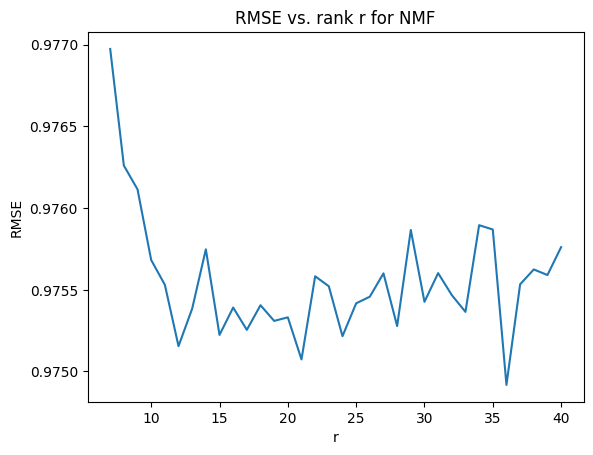

In [10]:
import matplotlib.pyplot as plt

plt.plot(rmse_nmf.keys(), rmse_nmf.values())

plt.xlabel("r")
plt.ylabel("RMSE")
plt.title("RMSE vs. rank r for NMF")

plt.show()

In [ ]:
Z_nmf_v2, u_nmf_v2, m_nmf_v2, rmse_nmf_v2 = train("C:/Users/Asia/Desktop/mocadr/MoviesRecommendations/data/ratings.csv", "NMF_V2")

preds_nmf_v2 = predict(
    "C:/Users/Asia/Desktop/mocadr/MoviesRecommendations/data/sample_test.csv",
    {"Z_approx": Z_nmf_v2, "user_map": u_nmf_v2, "movie_map": m_nmf_v2}
)

mse_nmf_v2 = mean_squared_error(df_true["rating"], preds_nmf_v2["rating"])
test_rmse_nmf_v2 = np.sqrt(mse_nmf_v2)

print(f"RMSE: {test_rmse_nmf_v2:.4f}")

plt.plot(rmse_nmf_v2.keys(), rmse_nmf_v2.values())

plt.xlabel("r")
plt.ylabel("RMSE")
plt.title("RMSE vs. rank r for NMF_V2")

plt.show()